In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# from bayes_opt import BayesianOptimization
from sklearn.preprocessing import label_binarize, MinMaxScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib import cm


import warnings, json, math, os
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.stats import norm

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, f1_score, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from scipy.spatial.distance import cdist


In [140]:
df = pd.read_csv("clean_df (1).csv")
df.shape

(2927, 117)

In [141]:
df.dtypes.value_counts()

int64      62
bool       38
float64    17
Name: count, dtype: int64

Ignoring Boolean Features Before PCA

PCA (Principal Component Analysis) is a linear dimensionality reduction method that identifies directions (principal components) which maximize the variance in the dataset.
Since PCA relies on covariance and continuous variance, it is most meaningful for numerical features that can vary smoothly across a range of values.

Our dataset also contains several boolean features (values True/False, encoded as 1/0). These features do not represent continuous measurements but categorical states, which have only two possible values and very limited variance. Including them in PCA would lead to the following issues:

Distorted variance structure: Boolean features can artificially reduce or dominate certain directions of variance, depending on their frequency distribution.

Inconsistent interpretation: PCA assumes linear relationships between features, which is not appropriate for binary categorical data.

Uninformative components: Because boolean features have little continuous variability, they contribute minimally to the total variance that PCA tries to capture.

For these reasons, only the scaled numerical (int and float) features are used for PCA in this analysis.
This ensures that the resulting principal components genuinely reflect the continuous variance structure of the dataset and that the explained variance ratios are meaningful.

In [142]:
df.isna().sum().sort_values(ascending=False).head(10)


MSZoning_encoded            2270
Lot Frontage                   0
Lot Area                       0
HouseStyle_MedianPrice         0
MS SubClass                    0
Neighborhood_MedianPrice       0
Combo_PriceMean                0
Overall Qual                   0
Overall Cond                   0
Year Built                     0
dtype: int64

For some reason the first feature in the above list is corupted and presents mostly NaN values so for the sake of sanity it will be droped.

In [143]:
df.drop('MSZoning_encoded', axis=1, inplace=True)

In [144]:
df.drop('SalePrice', axis=1, inplace=True)

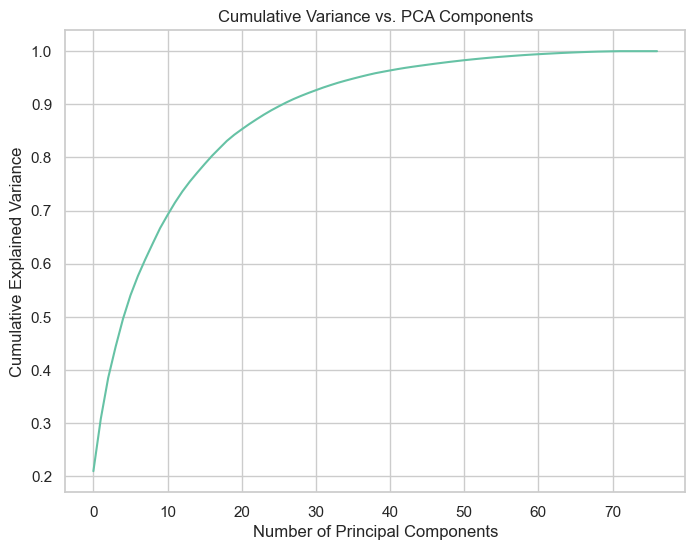

98% variance → 50 components
95% variance → 37 components
90% variance → 27 components
80% variance → 17 components


In [145]:
# Select numeric features (int + float)
scaler = MinMaxScaler()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
X_scaled = scaler.fit_transform(df[numerical_cols])

# Run PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Explained variance
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Plot
plt.plot(cumulative)
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance vs. PCA Components")
plt.grid(True)
plt.show()

# Find components for 98%, 95%, 90%, 80%
for target in [0.98, 0.95, 0.90, 0.80]:
    n = np.argmax(cumulative >= target) + 1
    print(f"{target*100:.0f}% variance → {n} components")
# Run PCA
pca = PCA()

In [146]:
targets = [0.80, 0.90, 0.95, 0.98]
reduced_datasets = {}

for target in targets:
    n = np.argmax(cumulative >= target) + 1
    pca = PCA(n_components=n)
    X_reduced = pca.fit_transform(X_scaled)
    reduced_datasets[target] = X_reduced
    print(f'Variance {target*100:.0f}% → {n} components → shape {X_reduced.shape}')

Variance 80% → 17 components → shape (2927, 17)
Variance 90% → 27 components → shape (2927, 27)
Variance 95% → 37 components → shape (2927, 37)
Variance 98% → 50 components → shape (2927, 50)


K-means clustering on each reduced dataset (according to explained variance). Uses elbow method (Within Cluster Sum of Squares) to find the optimal number of clusters (k)

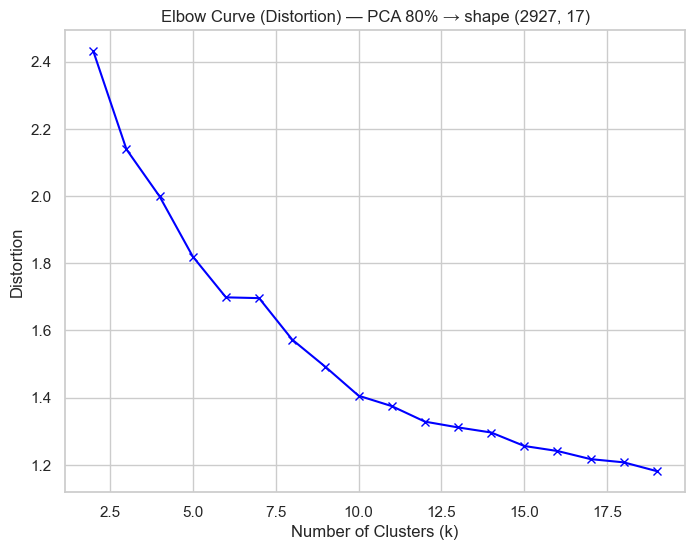

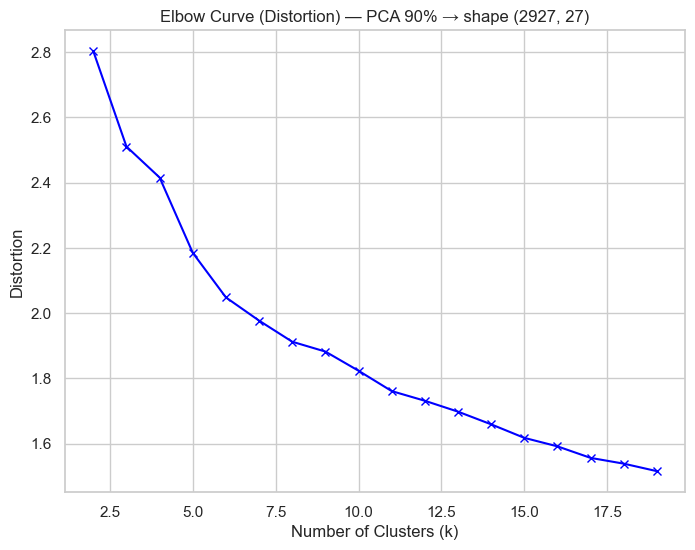

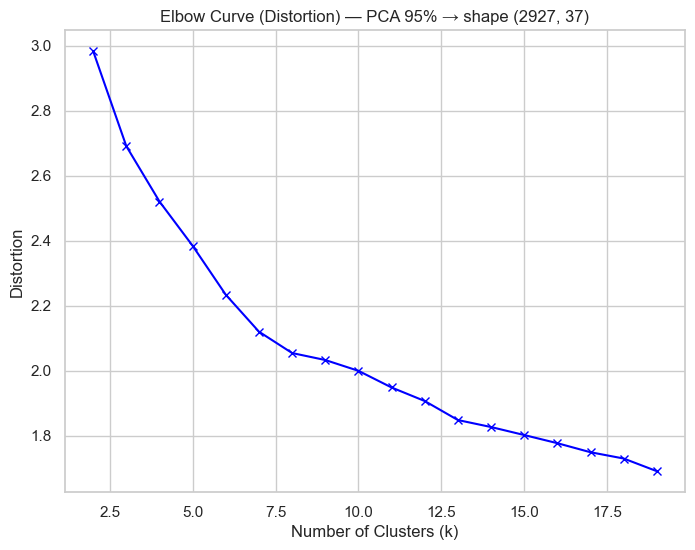

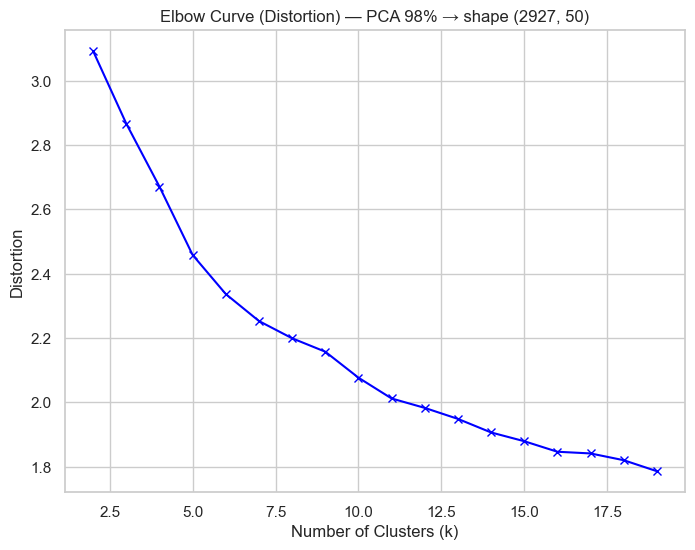


TOP 5 DISTORTION DROPS PER PCA VARIANCE

PCA 80% variance:
  k=2 → k=3 | 12.02% drop
  k=4 → k=5 | 8.94% drop
  k=7 → k=8 | 7.28% drop
  k=5 → k=6 | 6.67% drop
  k=3 → k=4 | 6.55% drop

PCA 90% variance:
  k=2 → k=3 | 10.43% drop
  k=4 → k=5 | 9.55% drop
  k=5 → k=6 | 6.25% drop
  k=3 → k=4 | 3.78% drop
  k=6 → k=7 | 3.47% drop

PCA 95% variance:
  k=2 → k=3 | 9.80% drop
  k=3 → k=4 | 6.32% drop
  k=5 → k=6 | 6.31% drop
  k=4 → k=5 | 5.41% drop
  k=6 → k=7 | 5.08% drop

PCA 98% variance:
  k=4 → k=5 | 7.95% drop
  k=2 → k=3 | 7.30% drop
  k=3 → k=4 | 6.83% drop
  k=5 → k=6 | 4.94% drop
  k=9 → k=10 | 3.74% drop


In [147]:
# dictionary to store percent drops per PCA dataset
percent_drops_per_target = {}

for target, X_reduced in reduced_datasets.items():
    distortions = []
    K = range(2, 20)

    # compute distortions
    for k in K:
        model = KMeans(n_clusters=k, random_state=42).fit(X_reduced)
        dist = np.min(cdist(X_reduced, model.cluster_centers_, 'euclidean'), axis=1)
        distortions.append(np.mean(dist**2))

    # percent decreases for this dataset
    percent_decreases = []
    for i in range(1, len(distortions)):
        old = distortions[i-1]
        new = distortions[i]
        percent = (old - new) / old * 100
        percent_decreases.append((K[i-1], K[i], percent))  # (k_old, k_new, percent)

    percent_drops_per_target[target] = percent_decreases

    # plot elbow
    plt.plot(K, distortions, 'bx-')
    plt.xlabel('Number of Clusters (k)')
    plt.ylabel('Distortion')
    plt.title(f'Elbow Curve (Distortion) — PCA {target*100:.0f}% → shape {X_reduced.shape}')
    plt.show()

print("\nTOP 5 DISTORTION DROPS PER PCA VARIANCE")

for target, drops in percent_drops_per_target.items():
    print(f"\nPCA {target*100:.0f}% variance:")
    
    best5 = sorted(drops, key=lambda x: x[2], reverse=True)[:5]
    
    for (k_old, k_new, percent) in best5:
        print(f"  k={k_old} → k={k_new} | {percent:.2f}% drop")


In [148]:
def plot_full_silhouette(X, labels, k, title):
    fig, ax = plt.subplots(figsize=(8, 6))
    silhouette_vals = silhouette_samples(X, labels)
    silhouette_avg = np.mean(silhouette_vals)

    y_lower = 10
    for i in range(k):
        ith_vals = silhouette_vals[labels == i]
        ith_vals.sort()
        size = ith_vals.shape[0]
        y_upper = y_lower + size

        color = cm.nipy_spectral(float(i) / k)
        ax.fill_betweenx(np.arange(y_lower, y_upper),
                         0, ith_vals,
                         facecolor=color, edgecolor=color, alpha=0.7)

        ax.text(-0.05, y_lower + size / 2.0, str(i), fontsize=8)
        y_lower = y_upper + 10

    ax.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax.set_title(title)
    ax.set_xlabel("Silhouette value")
    ax.set_ylabel("Cluster")
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()


In [149]:
def plot_pca_scatter(X_reduced, labels, centers, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=labels, cmap="tab10", s=25)
    plt.scatter(centers[:, 0], centers[:, 1],
                c="black", marker="x", s=120, label="Centers")
    plt.title(title)
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend()
    plt.tight_layout()
    plt.show()


Here we have the scater plot of the main 2 PCA's with clustering based on the nr of clusters taken form the elbow method(eye test)


=== PCA 80% Variance — 17 components ===


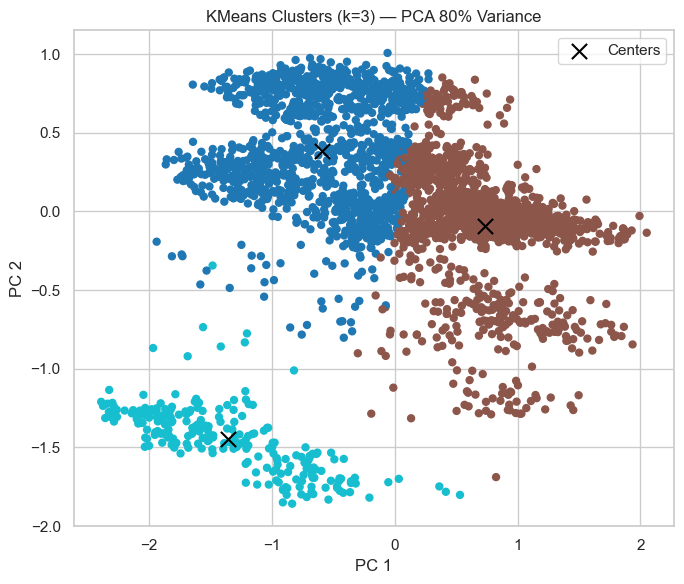


=== PCA 90% Variance — 27 components ===


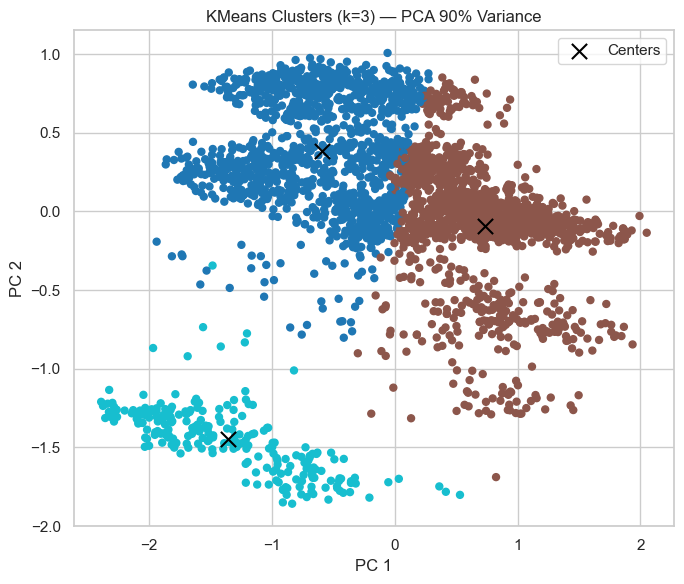


=== PCA 95% Variance — 37 components ===


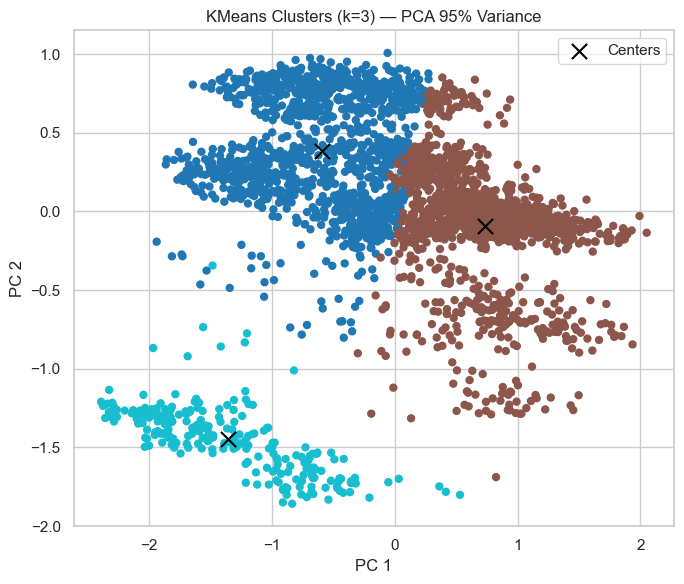


=== PCA 98% Variance — 50 components ===


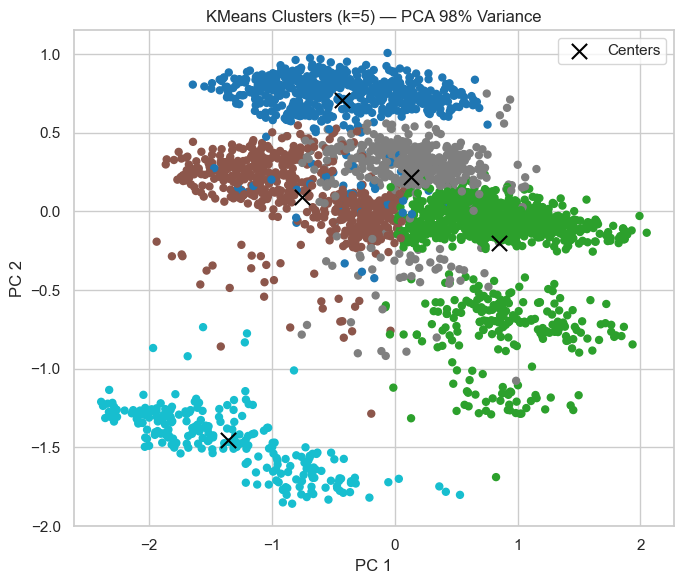

In [150]:
optimal_clusters = {
    0.80: 3,
    0.90: 3,
    0.95: 3,
    0.98: 5,
}

for target, X_reduced in reduced_datasets.items():
    print(f"\n=== PCA {target*100:.0f}% Variance — {X_reduced.shape[1]} components ===")

    k_opt = optimal_clusters[target]

    kmeans = KMeans(n_clusters=k_opt, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    centers = kmeans.cluster_centers_
    sil = silhouette_score(X_reduced, labels)


    plot_pca_scatter(
        X_reduced,
        labels,
        centers,
        title=f"KMeans Clusters (k={k_opt}) — PCA {target*100:.0f}% Variance"
    )


The clusters resulting from these have messy margins and do not look right


=== PCA 80% Variance — 17 components ===


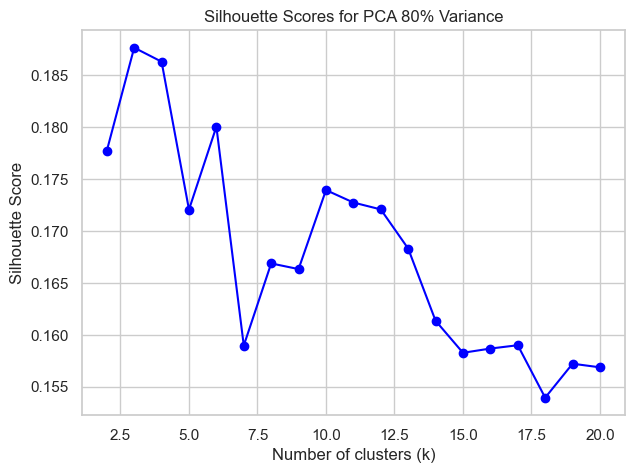

Best k according to silhouette score = 3 (score = 0.1877)

=== PCA 90% Variance — 27 components ===


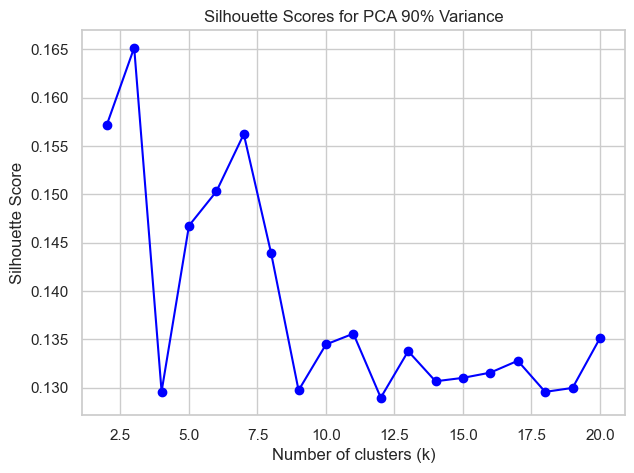

Best k according to silhouette score = 3 (score = 0.1652)

=== PCA 95% Variance — 37 components ===


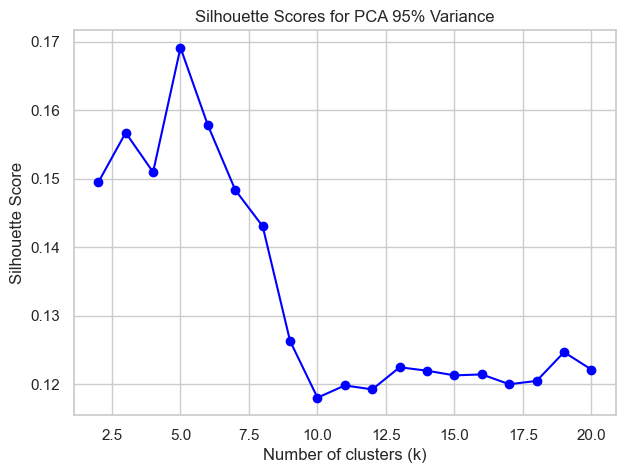

Best k according to silhouette score = 5 (score = 0.1691)

=== PCA 98% Variance — 50 components ===


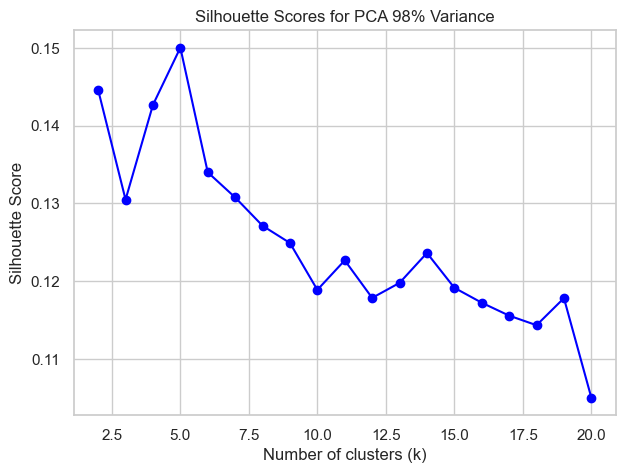

Best k according to silhouette score = 5 (score = 0.1500)


In [151]:
best_k_for_each = {}

for target, X_reduced in reduced_datasets.items():
    print(f"\n=== PCA {target*100:.0f}% Variance — {X_reduced.shape[1]} components ===")

    k_range = range(2, 21)
    sil_scores = []

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(X_reduced)
        labels = kmeans.labels_
        sil = silhouette_score(X_reduced, labels)
        sil_scores.append(sil)

    plt.figure(figsize=(7, 5))
    plt.plot(k_range, sil_scores, "bo-")
    plt.title(f"Silhouette Scores for PCA {target*100:.0f}% Variance")
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.grid(True)
    plt.show()

    best_index = np.argmax(sil_scores)
    best_k = k_range[best_index]

    best_k_for_each[target] = best_k
    print(f"Best k according to silhouette score = {best_k} (score = {sil_scores[best_index]:.4f})")

The values found for k are the same with the ones found with the elbow method but for comparison of the 2 we will plot the main 2 PCA's of the clustering with some local maximums of the sil scores.


=== PCA 80% Variance — 17 components ===


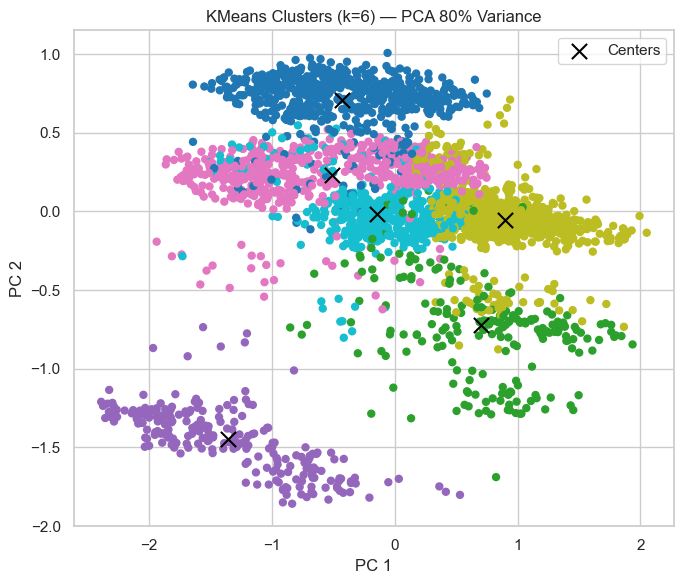


=== PCA 90% Variance — 27 components ===


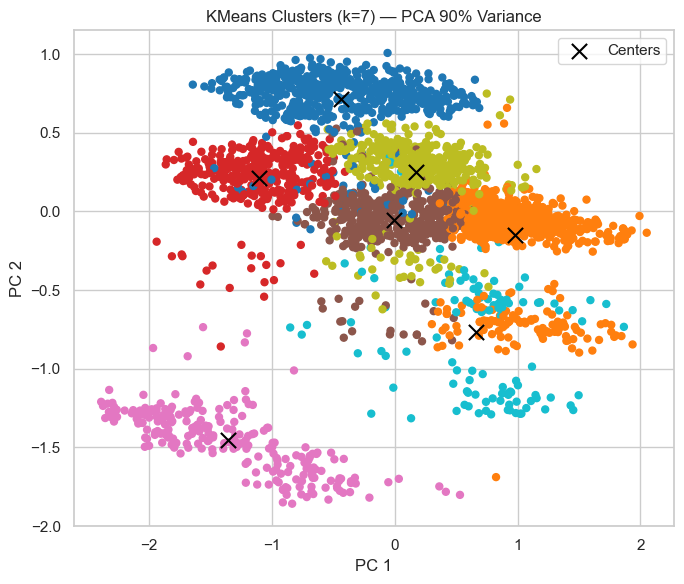


=== PCA 95% Variance — 37 components ===


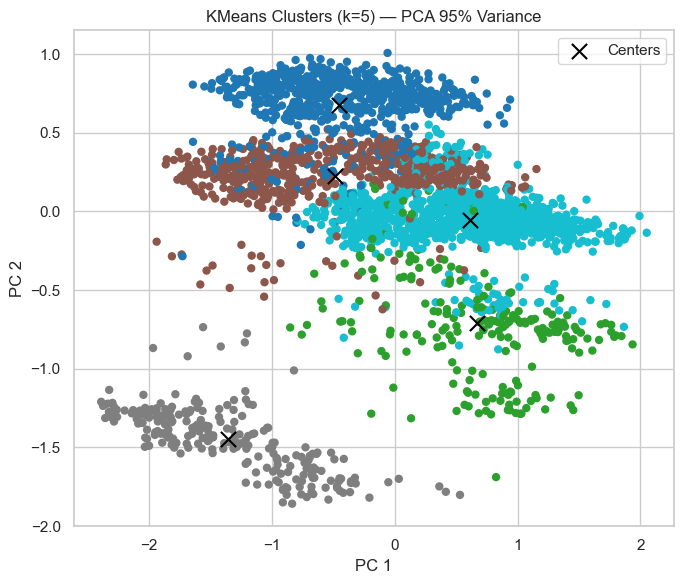


=== PCA 98% Variance — 50 components ===


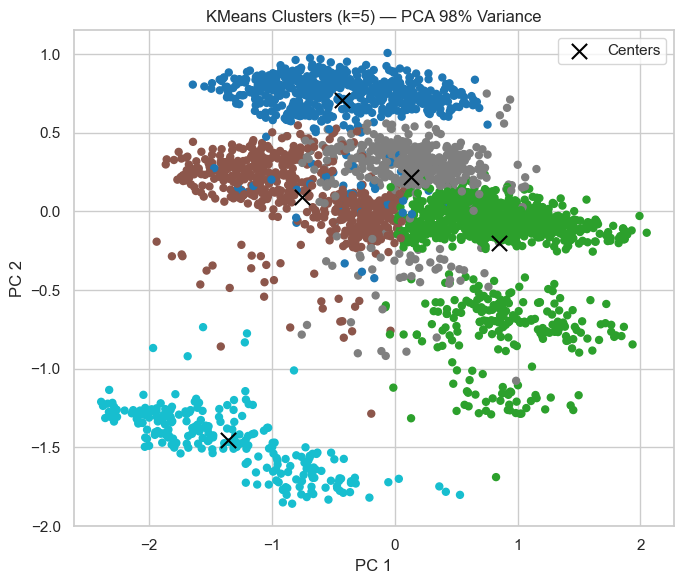

In [152]:
optimal_clusters = {
    0.80: 6,
    0.90: 7,
    0.95: 5,
    0.98: 5,
}

for target, X_reduced in reduced_datasets.items():
    print(f"\n=== PCA {target*100:.0f}% Variance — {X_reduced.shape[1]} components ===")

    k_opt = optimal_clusters[target]

    kmeans = KMeans(n_clusters=k_opt, random_state=42)
    labels = kmeans.fit_predict(X_reduced)
    centers = kmeans.cluster_centers_


    plot_pca_scatter(
        X_reduced,
        labels,
        centers,
        title=f"KMeans Clusters (k={k_opt}) — PCA {target*100:.0f}% Variance"
    )


Interpretation of the clustering results (Elbow, Silhouette & PCA scatter plots)

For each PCA–reduced version of the dataset (80 %, 90 %, 95 % and 98 % explained variance) I trained a separate k-Means model and evaluated different numbers of clusters.

1) Elbow method

For all four PCA variants, the distortion drops very strongly when going from k = 1 → 2 and 2 → 3.

After that, the additional decrease becomes much smaller and the curves start to “bend”, which is the typical elbow shape.

Visually, this suggests a relatively small number of “big” clusters (around 3–5) for most PCA settings. The 98 % PCA sometimes allows slightly larger k because more variance (structure) is preserved.

2) Silhouette scores for different k

I then computed the silhouette score for k = 2 … 20 on each PCA-reduced dataset.

The silhouette curves usually show a clear maximum (or a few local maxima) at relatively small k values, and then gradually decrease as k becomes very large.

This means that splitting the data into a few coherent, well-separated clusters works better than forcing many small clusters.

The best-scoring k’s largely agree with the “elbow” locations from the distortion plots, which is a good sign: both methods point to similar cluster complexity.

3) Scatter plots of the first two principal components

The scatter plots show the first two principal components on the axes and color the points by cluster.

For lower PCA variance (e.g. 80 %), the clusters appear more coarse and overlapping: mostgroups are visible, but the boundaries are fuzzy and points spill over into neighboring clusters.

As the retained variance increases (90 %, 95 %, 98 %), the clusters generally become more structured: some groups get tighter and better separated, and the decision boundaries look less random.

However, even at high variance the clusters in the 2-D plot are not perfectly separated, because we only see PC1 and PC2. Some separation happens in higher components that are not visible in the 2-D projection. This also explains why a higher-dimensional PCA (e.g. 95 % or 98 %) can justify a larger k than what we’d guess from the 2-D scatter alone.

4) Differences

Between PCA levels: With more explained variance (more components), k-Means can exploit more structure in the data. This tends to increase the “optimal” k suggested by the silhouette score and produces slightly more detailed clusters, but at the cost of more complex, less visually obvious boundaries in 2-D.

Between k choices: Very small k merges distinct regions into broad clusters (high silhouette only if the data is very simple), while very large k creates small, noisy clusters with lower silhouette scores. The “good” k values lie where silhouette is high and the elbow curve shows a clear bend.

Overall, the results show that PCA helps make the high-dimensional clusterable, and that both elbow and silhouette methods consistently favor a moderate number of clusters. The scatter plots confirm that the chosen k values capture meaningful structure but also illustrate that not all cluster separations are visible in just the first two principal components.

In [153]:
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

In [154]:
loading_df = pd.DataFrame(
    loadings[:, :2],  # first 2 PCs
    columns=["PC1", "PC2"],
    index=numerical_cols
)


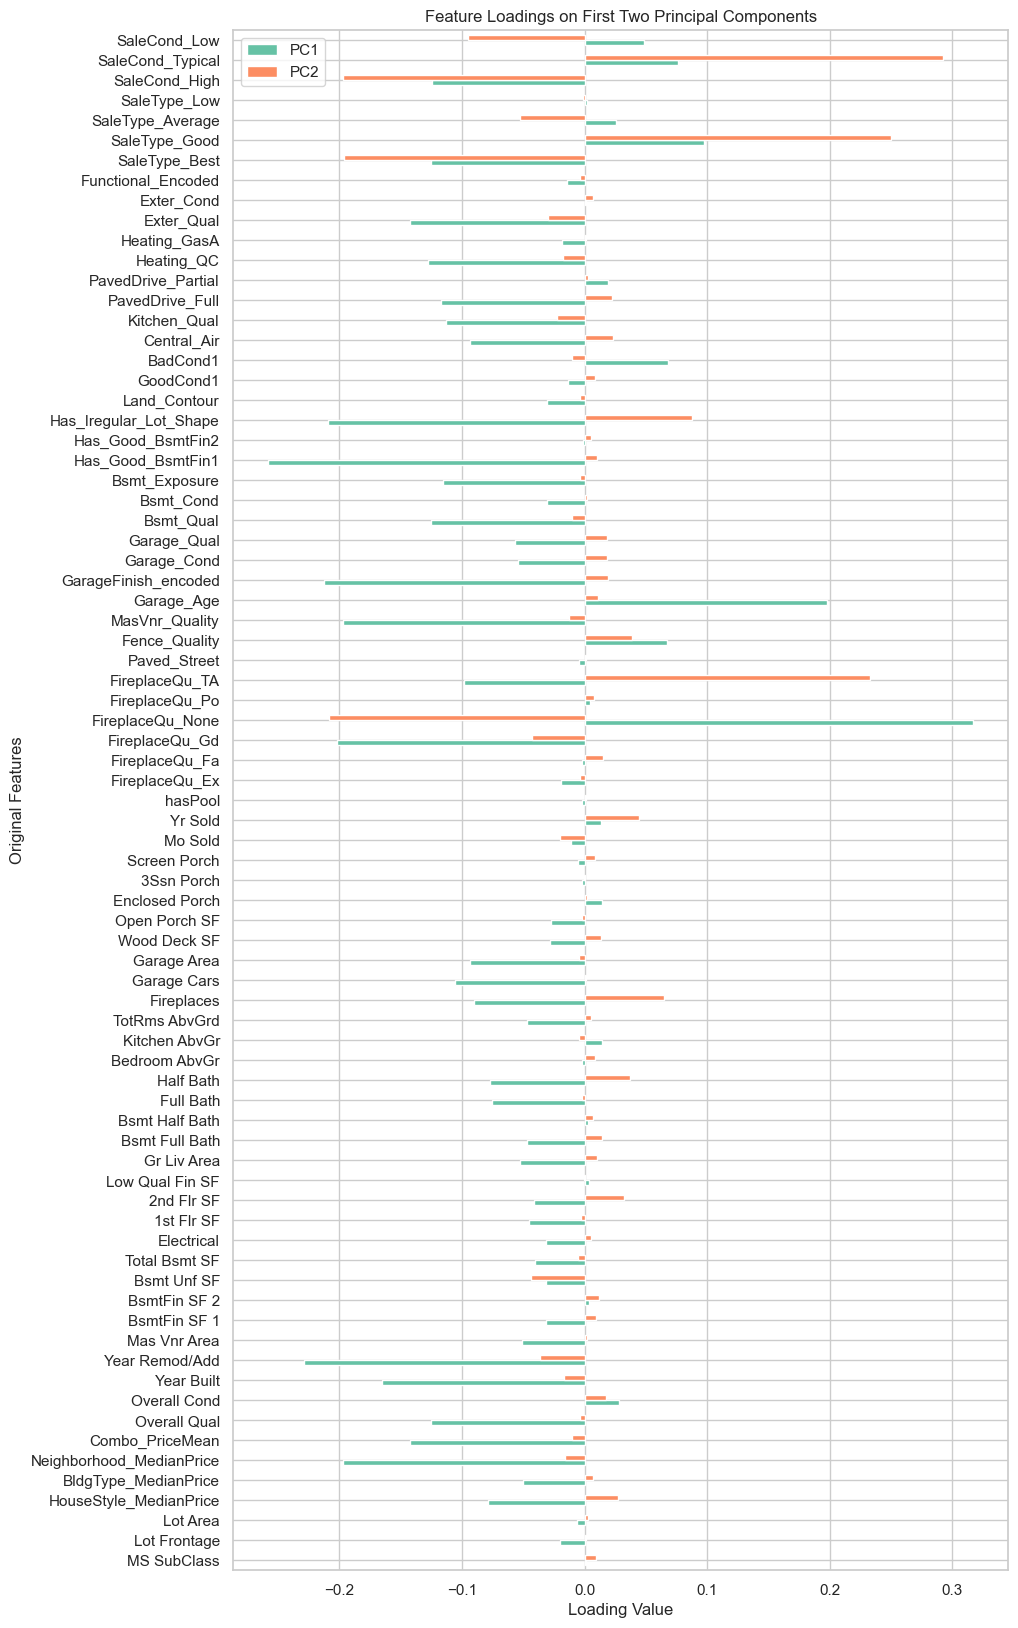

In [155]:
loading_df.plot(kind='barh', figsize=(10, 20))
plt.title("Feature Loadings on First Two Principal Components")
plt.xlabel("Loading Value")      # now X-axis shows loadings
plt.ylabel("Original Features")  # Y-axis shows feature names
plt.grid(True)
plt.show()


Interpretation of the First Two Principal Components
1) Principal Component 1 (PC1)

PC1 shows strong positive loadings for these features:
FireplaceQu_None
GarageAge
BadCond1
SaleCond low and typical
SaleType Avg and Good
Fence Quality



Interpretation:
PC1 is a “” axis.

2) Principal Component 2 (PC2)

PC2 shows strong positive loadings for these features:
SaleCond Typical
SaleType Good


Interpretation:
PC2 is an “” axis.



Together:

PC1 separates homes by overall size, structural characteristics, and fundamental build quality.

PC2 separates homes by the presence of amenities, upgrades, and condition-related characteristics.

These two axes allow us to interpret the cluster plots:
